In [2]:
import kagglehub
import os

# 1. Download the "Cleaned" version (no Thumbs.db, no corrupt JPEGs)
path = kagglehub.dataset_download("tongpython/cat-and-dog")

# 2. Point to the folders provided in this specific dataset
train_dir = os.path.join(path, 'training_set/training_set')
test_dir = os.path.join(path, 'test_set/test_set')

print(f"✅ Data is ready!")
print(f"Train Path: {train_dir}")

Using Colab cache for faster access to the 'cat-and-dog' dataset.
✅ Data is ready!
Train Path: /kaggle/input/cat-and-dog/training_set/training_set


In [3]:
import tensorflow as tf


train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    seed=123,
    image_size=(200, 200),
    batch_size=32
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    seed=123,
    image_size=(200, 200),
    batch_size=32
)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


In [1]:
import tensorflow
from tensorflow import keras
from keras.layers import Flatten, Dense
from keras import Sequential
from keras.applications.vgg16 import VGG16

In [4]:
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(200, 200, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [5]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model =  Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,433,793 (74.13 MB)

 Trainable params: 19,433,793 (74.13 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
conv_base.trainable = False

In [9]:
# Conv base trainable params freezed
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,433,793 (74.13 MB)

 Trainable params: 4,719,105 (18.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
# Normalize

def process(image, label):
  image = tf.cast(image/255., tf.float32)
  return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [11]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [12]:
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 73s 225ms/step - accuracy: 0.8800 - loss: 0.3363 - val_accuracy: 0.8997 - val_loss: 0.2454
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 54s 216ms/step - accuracy: 0.9438 - loss: 0.1394 - val_accuracy: 0.8987 - val_loss: 0.2630
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 54s 217ms/step - accuracy: 0.9649 - loss: 0.0895 - val_accuracy: 0.8972 - val_loss: 0.2630
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 55s 218ms/step - accuracy: 0.9758 - loss: 0.0615 - val_accuracy: 0.8828 - val_loss: 0.3674
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 54s 216ms/step - accuracy: 0.9775 - loss: 0.0588 - val_accuracy: 0.9100 - val_loss: 0.2895
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 54s 217ms/step - accuracy: 0.9915 - loss: 0.0283 - val_accuracy: 0.9199 - val_loss: 0.2687
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 55s 217ms/step - accuracy: 0.9934 - loss: 0.0212 - val_accuracy: 0.8972 - val_loss: 0.3986
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 55s 218ms/step - accuracy: 0.9965 - loss: 0

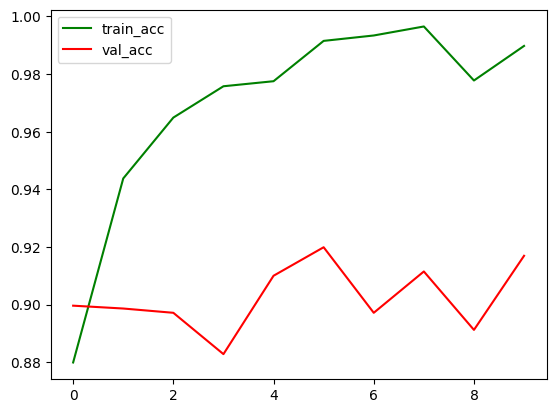

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color='green', label='train_acc')
plt.plot(history.history['val_accuracy'], color='red', label='val_acc')
plt.legend()
plt.show()

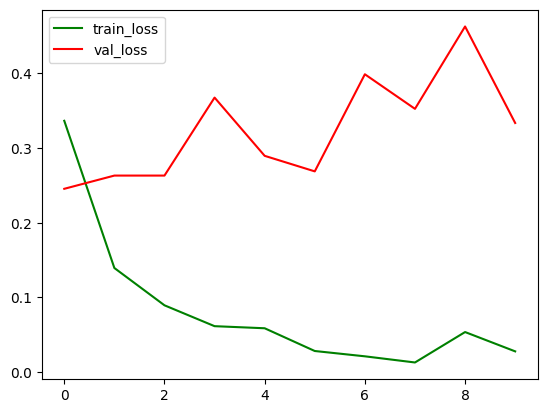

In [15]:
plt.plot(history.history['loss'], color='green', label='train_loss')
plt.plot(history.history['val_loss'], color='red', label='val_loss')
plt.legend()
plt.show()